In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [45]:
## 1. Data Loading

df = pd.read_csv("US_Accidents_March23.csv", low_memory=False) 

df.shape

(7728394, 46)

In [46]:
#2. External Data Preparation (ZIP to County and RUCC)
def read_with_fallback(path, sep=None):
    encodings_to_try = ["utf-8", "utf-8-sig", "cp1252", "latin1", "ISO-8859-1"]
    last_err = None
    for enc in encodings_to_try:
        try:
            return pd.read_csv(path, sep=sep, dtype=str, encoding=enc, engine="python")
        except Exception as e:
            last_err = e
    raise last_err

# 1) Load the ZCTA->County file (pipe-delimited)
zip_county = read_with_fallback("tab20_zcta520_county20_natl.txt", sep="|")
print("zip_county loaded:", zip_county.shape)
print(zip_county.head(2))

# 2) Load RUCC (comma-delimited)
rucc = read_with_fallback("RUCC.csv", sep=",")
print("rucc loaded:", rucc.shape)
print(rucc.head(2))

zip_county loaded: (47863, 18)
  OID_ZCTA5_20 GEOID_ZCTA5_20 NAMELSAD_ZCTA5_20 AREALAND_ZCTA5_20  \
0          NaN            NaN               NaN               NaN   
1          NaN            NaN               NaN               NaN   

  AREAWATER_ZCTA5_20 MTFCC_ZCTA5_20 CLASSFP_ZCTA5_20 FUNCSTAT_ZCTA5_20  \
0                NaN            NaN              NaN               NaN   
1                NaN            NaN              NaN               NaN   

    OID_COUNTY_20 GEOID_COUNTY_20 NAMELSAD_COUNTY_20 AREALAND_COUNTY_20  \
0  27590114112812           01003     Baldwin County         4117656199   
1   2759099719300           01007        Bibb County         1612188717   

  AREAWATER_COUNTY_20 MTFCC_COUNTY_20 CLASSFP_COUNTY_20 FUNCSTAT_COUNTY_20  \
0          1132956041           G4020                H1                  A   
1             9572303           G4020                H1                  A   

  AREALAND_PART AREAWATER_PART  
0     339765765      927218265  
1      9270

In [47]:
df.info()   
df.head()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [48]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [49]:
# Keep only needed columns
zc = zip_county[['GEOID_ZCTA5_20', 'GEOID_COUNTY_20', 'AREALAND_PART']].copy()

# Convert land area to numeric
zc['AREALAND_PART'] = pd.to_numeric(zc['AREALAND_PART'], errors='coerce')

# Sort by land overlap descending
zc = zc.sort_values('AREALAND_PART', ascending=False)

# Keep dominant county per ZIP
zc_dom = (
    zc.drop_duplicates(subset=['GEOID_ZCTA5_20'])
      .rename(columns={
          'GEOID_ZCTA5_20': 'Zipcode',
          'GEOID_COUNTY_20': 'county_fips'
      })
)

zc_dom.head()

,Zipcode,county_fips,AREALAND_PART
39,NaN,02290,254104080132
47633,99557,02050,35426845132
47649,99576,02070,29607891619
47640,99566,02066,24385142667
47781,99740,02290,20827221156


In [50]:
df['Zipcode'] = df['Zipcode'].astype(str).str.extract(r'(\d{5})')[0]
df['Zipcode'] = df['Zipcode'].str.zfill(5)

In [51]:
df = df.merge(zc_dom[['Zipcode', 'county_fips']], on='Zipcode', how='left')

print("Missing county_fips:", df['county_fips'].isna().mean())

Missing county_fips: 0.00040254158884756654


In [52]:

rucc.columns = rucc.columns.str.strip().str.lower()
rucc.columns

Index(['fips', 'state', 'county_name', 'attribute', 'value'], dtype='str')

In [53]:
rucc['attribute'].unique()

rucc_rucc = rucc[rucc['attribute'] == 'RUCC_2023'].copy()

rucc_rucc.head()

,fips,state,county_name,attribute,value
1,01001,AL,Autauga County,RUCC_2023,2
4,01003,AL,Baldwin County,RUCC_2023,3
7,01005,AL,Barbour County,RUCC_2023,6
10,01007,AL,Bibb County,RUCC_2023,1
13,01009,AL,Blount County,RUCC_2023,1


In [54]:
rucc_clean = rucc_rucc[['fips', 'value']].copy()

rucc_clean = rucc_clean.rename(columns={
    'fips': 'county_fips',
    'value': 'rucc'
})

rucc_clean['county_fips'] = rucc_clean['county_fips'].astype(str).str.zfill(5)
rucc_clean['rucc'] = pd.to_numeric(rucc_clean['rucc'], errors='coerce')

rucc_clean.head()

,county_fips,rucc
1,01001,2
4,01003,3
7,01005,6
10,01007,1
13,01009,1


In [55]:
df = df.merge(rucc_clean, on='county_fips', how='left')

print("Missing RUCC:", df['rucc'].isna().mean())

Missing RUCC: 0.009593454992072092


In [56]:
df['is_rural'] = (df['rucc'] >= 4).astype(int)

df['is_rural'].value_counts(normalize=True)

is_rural
0    0.933396
1    0.066604
Name: proportion, dtype: float64

In [57]:
df.groupby('is_rural')['Severity'].value_counts(normalize=True)

is_rural  Severity
0         2           0.794259
          3           0.173805
          4           0.022885
          1           0.009052
1         2           0.830467
          3           0.088532
          4           0.076988
          1           0.004014
Name: proportion, dtype: float64

In [58]:
df.groupby(['is_rural', 'Nautical_Twilight'])['Severity'].mean()

is_rural  Nautical_Twilight
0         Day                  2.207870
          Night                2.221373
1         Day                  2.243071
          Night                2.220653
Name: Severity, dtype: float64

In [59]:
df.groupby(['is_rural', 'Nautical_Twilight'])['Severity'].value_counts(normalize=True)

is_rural  Nautical_Twilight  Severity
0         Day                2           0.790871
                             3           0.179591
                             4           0.019272
                             1           0.010266
          Night              2           0.806251
                             3           0.153035
                             4           0.036351
                             1           0.004363
1         Day                2           0.820384
                             3           0.101621
                             4           0.073149
                             1           0.004847
          Night              2           0.857049
                             4           0.081549
                             3           0.059479
                             1           0.001923
Name: proportion, dtype: float64

In this analysis, severe crashes are defined as accidents with Severity levels 3 or 4.  
These levels represent incidents involving significant injury or substantial roadway impact, making them particularly relevant for transportation safety policy.

In [60]:
df['is_severe'] = df['Severity'].isin([3,4]).astype(int)


In [61]:
import statsmodels.formula.api as smf

df['is_night'] = (df['Nautical_Twilight'] == 'Night').astype(int)

model = smf.logit(
    "is_severe ~ is_night + is_rural + is_night:is_rural",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.492544
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              is_severe   No. Observations:              7728394
Model:                          Logit   Df Residuals:                  7728390
Method:                           MLE   Df Model:                            3
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:               0.0006069
Time:                        21:22:16   Log-Likelihood:            -3.8066e+06
converged:                       True   LL-Null:                   -3.8089e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.3952      0.001  -1332.224      0.000      -1.397      -1.393
is_night

In [ ]:
import seaborn as sns

sns.barplot(
    data=df,
    x="is_night",
    y="is_severe",
    hue="is_rural"
)

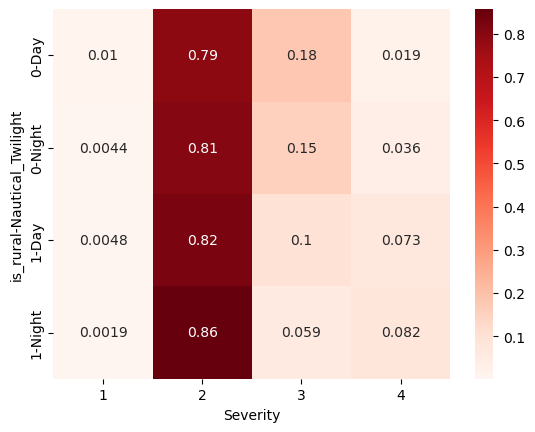

In [ ]:


table = pd.crosstab(
    [df['is_rural'], df['Nautical_Twilight']],
    df['Severity'],
    normalize='index'
)

sns.heatmap(table, annot=True, cmap="Reds")
plt.show()

In [ ]:
tableau_df = df[['Start_Lat',
                 'Start_Lng',
                 'Zipcode',
                 'Severity',
                 'is_rural',
                 'is_night',
                 'State',
                 'City',
                 'County']].copy()

tableau_df = tableau_df[tableau_df['Severity'] >= 3]

tableau_df.to_csv("severe_accidents_tableau.csv", index=False)

print("Export complete")

Export complete


## Key Findings

1. Rural crashes account for a smaller share of all crashes, but they show a higher proportion of the most severe outcomes.
2. Nighttime conditions are associated with changes in crash severity, especially when combined with rural settings.
3. Severe crashes (Severity 3–4) can be exported for spatial hotspot analysis in Tableau to identify priority intervention areas.

## TABLEAU

https://public.tableau.com/app/profile/jordan.baldoceda.pizarro/viz/USSevereTrafficAccidentRiskAnalysis/Story1?publish=yes

## RECOMMENDATIONS

Recommendation 1

IMPROVE LIGHTING AND ROAD SIGNAGE IN RURAL ACCIDENT HOTSPOTS


Transportation agencies should prioritize installing improved roadway lighting, reflective signage, and lane markings in rural accident hotspots, particularly in areas where severe crashes frequently occur at night.

DATA SUPPORT

The analysis shows that severe accidents occur more frequently at night and are more severe in rural areas, indicating that reduced visibility likely contributes to higher crash severity.

POTENTIAL IMPACT

Improved lighting and reflective infrastructure can help drivers detect road conditions, obstacles, and curves earlier, reducing the likelihood of high-severity crashes.

CHALLENGES

Infrastructure improvements require significant funding

Some rural areas have limited electrical infrastructure

Implementation may require coordination between state and local agencies

METRICS FOR MEASURING EFFECTIVENESS

Transportation agencies could track:

Reduction in nighttime severe accident rates

Changes in severity level distribution (Severity 3–4 crashes)

Accident frequency before and after lighting improvements

Recommendation 2

IMPLEMENT REDUCED SPEED LIMITS DURING NIGHTTIME IN HIGH-RISK RURAL ROADS

State transportation agencies should consider implementing lower speed limits at night on rural roads, particularly after nautical twilight, when visibility decreases significantly.

DATA SUPPORT

The analysis indicates that nighttime driving increases the risk of severe accidents, especially in rural environments where higher speeds and lower visibility are common.

POTENTIAL IMPACT

Lower nighttime speed limits can reduce impact force during collisions, giving drivers more time to react and potentially lowering accident severity.

CHALLENGES

Enforcing variable speed limits may require additional traffic enforcement

Drivers may be less aware of changing nighttime speed regulations

Implementation may require new signage and public education campaigns

METRICS FOR MEASURING EFFECTIVENESS

Effectiveness could be evaluated through:

Reduction in nighttime severe crash rates

Changes in average vehicle speed during nighttime hours

Comparison of accident severity before and after policy implementation

Recommendation 3

CONDUCT STATE-LEVEL SAFETY REVIEWS IN HIGH-CLUSTER REGIONS

Transportation agencies should conduct targeted safety audits in states and regions with high concentrations of severe accident clusters, particularly near major transportation corridors and coastal population centers.

DATA SUPPORT

The geographic analysis shows that severe accidents cluster in specific regions, indicating that local roadway design, traffic density, or environmental factors may influence accident risk.

POTENTIAL IMPACT

Targeted safety reviews can identify location-specific hazards such as:

dangerous intersections

poor roadway design

insufficient traffic control measures

Addressing these issues can significantly reduce accident severity.

CHALLENGES

Safety audits require coordination across multiple jurisdictions

Infrastructure improvements may involve high costs and long implementation timelines

Some accident patterns may be influenced by driver behavior rather than infrastructure

METRICS FOR MEASURING EFFECTIVENESS

Transportation agencies could monitor:

Reduction in accident clusters over time

Changes in severe accident rates in targeted regions

Improvements in traffic safety indicators after infrastructure modifications